# 03 — Model Training & Evaluation
## Used Car Price Prediction

**Purpose:** Train and compare multiple ML models on the preprocessed dataset. Select the best model for XAI analysis.

### Models
| Model | Type | Why |
|---|---|---|
| Ridge Regression | Linear | Interpretable baseline |
| Random Forest | Ensemble / tree | Handles non-linearity, feature importance |
| XGBoost | Gradient boosting | State-of-the-art tabular performance |
| LightGBM | Gradient boosting | Faster alternative to XGBoost |

### Evaluation Metrics
- **RMSE** (on log-price scale)
- **MAE** (on original price scale after back-transformation)
- **R²** (explained variance)
- **MAPE** (for business communicability)


**Picks up from:** `df_train`, `df_val`, `df_test`, `FEATURE_COLS`, `TARGET` stored at the end of Notebook 02.

### Contents
1. [Setup & Restore from Preprocessing](#1-setup)
2. [Baseline — Ridge Regression](#2-ridge)
3. [Random Forest](#3-rf)
4. [XGBoost](#4-xgb)
5. [LightGBM](#5-lgbm)
6. [Model Comparison](#6-compare)
7. [Best Model — Validation Deep-Dive](#7-deepdive)
8. [Save Best Model](#8-save)

---
## 1. Setup & Restore from Preprocessing <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sys.path.insert(0, str(Path().resolve().parent / 'src'))
from models import evaluate, compare_models, rmse

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
SEED = 42

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Retrieve variables stored at the end of 02_Preprocessing.ipynb
%store -r df_train
%store -r df_val
%store -r df_test
%store -r FEATURE_COLS
%store -r TARGET

print('Restored from Preprocessing:')
for name, obj in [('df_train', df_train), ('df_val', df_val), ('df_test', df_test)]:
    print(f'  {name:<12}: {len(obj):>7,} rows  x  {obj.shape[1]} cols')
print(f'  FEATURE_COLS: {len(FEATURE_COLS)} features')
print(f'  TARGET      : {TARGET}')

Restored from Preprocessing:
  df_train    : 223,340 rows  x  54 cols
  df_val      :  74,447 rows  x  54 cols
  df_test     :  74,447 rows  x  54 cols
  FEATURE_COLS: 45 features
  TARGET      : log_price


In [3]:
# Build feature matrices — drop rows where any feature is NaN (lat/long may still be NaN)
df_train_m = df_train[FEATURE_COLS + [TARGET]].dropna()
df_val_m   = df_val[FEATURE_COLS + [TARGET]].dropna()
df_test_m  = df_test[FEATURE_COLS + [TARGET]].dropna()

X_train, y_train = df_train_m[FEATURE_COLS].values, df_train_m[TARGET].values
X_val,   y_val   = df_val_m[FEATURE_COLS].values,   df_val_m[TARGET].values
X_test,  y_test  = df_test_m[FEATURE_COLS].values,  df_test_m[TARGET].values

print(f'X_train : {X_train.shape}   y_train mean: {y_train.mean():.3f}')
print(f'X_val   : {X_val.shape}   y_val   mean: {y_val.mean():.3f}')
print(f'X_test  : {X_test.shape}   y_test  mean: {y_test.mean():.3f}')

X_train : (221332, 45)   y_train mean: 9.530
X_val   : (73753, 45)   y_val   mean: 9.530
X_test  : (73778, 45)   y_test  mean: 9.532


---
## 2. Baseline — Ridge Regression <a id='2-ridge'></a>

Ridge regression serves as our **interpretable linear baseline**. We use a pipeline with `StandardScaler` since Ridge is sensitive to feature scale. Performance here sets the floor, any non-linear model should beat it.

In [4]:
t0 = time.time()

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=10.0, random_state=SEED))
])
ridge.fit(X_train, y_train)

print(f'Ridge trained in {time.time() - t0:.1f}s')

res_ridge_train = evaluate(ridge, X_train, y_train, label='Ridge')
res_ridge_val   = evaluate(ridge, X_val,   y_val,   label='Ridge')

for label, res in [('Train', res_ridge_train), ('Validation', res_ridge_val)]:
    print(f'\n── {label} ──────────────────────────────')
    print(f"  RMSE (log) : {res['rmse_log']:.4f}")
    print(f"  MAE  (USD) : ${res['mae_usd']:,.0f}")
    print(f"  R²         : {res['r2']:.4f}")
    print(f"  MAPE       : {res['mape']:.1f}%")

Ridge trained in 0.3s

── Train ──────────────────────────────
  RMSE (log) : 0.6075
  MAE  (USD) : $6,172
  R²         : 0.5479
  MAPE       : 70.0%

── Validation ──────────────────────────────
  RMSE (log) : 0.6093
  MAE  (USD) : $6,167
  R²         : 0.5453
  MAPE       : 71.2%


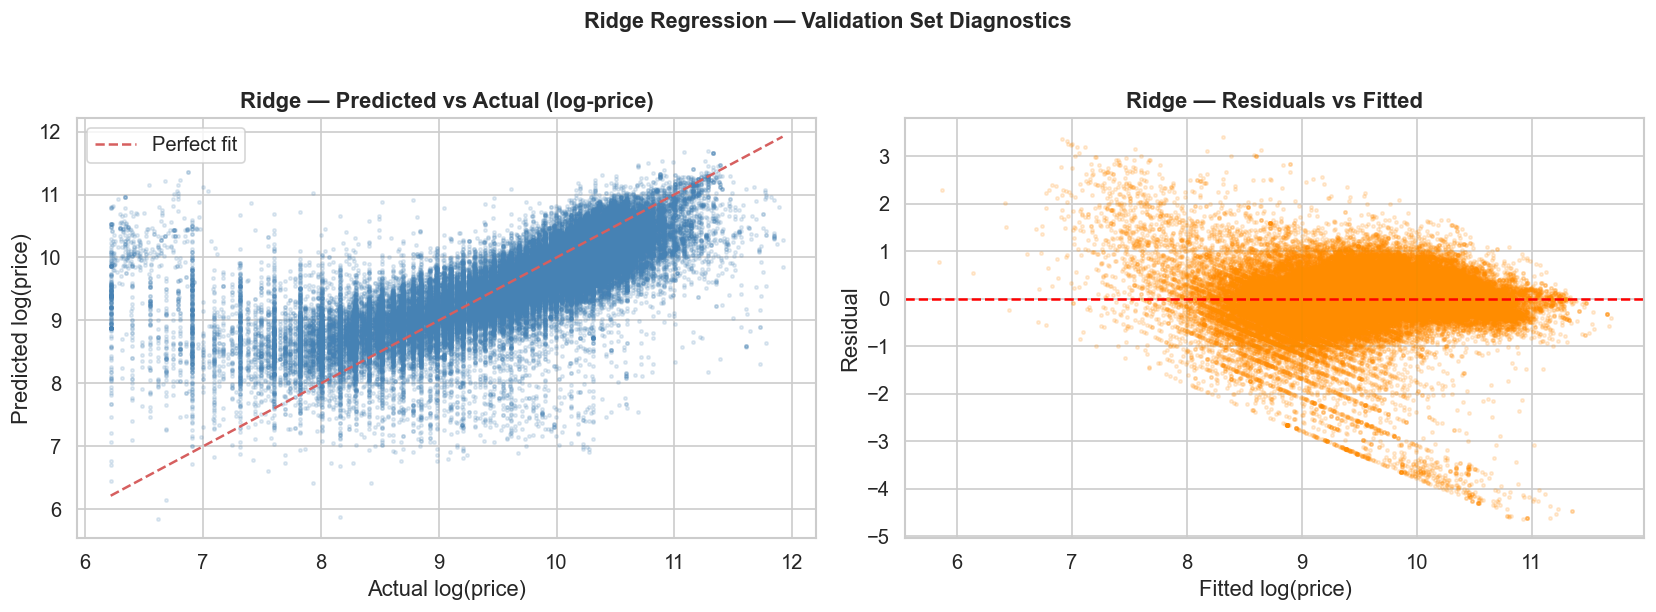

In [5]:
# Predicted vs actual and residuals
y_pred_ridge = ridge.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_val, y_pred_ridge, alpha=0.15, s=4, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Ridge — Predicted vs Actual (log-price)', fontweight='bold')
axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].legend()

# Residuals
residuals = y_val - y_pred_ridge
axes[1].scatter(y_pred_ridge, residuals, alpha=0.15, s=4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Ridge — Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted log(price)')
axes[1].set_ylabel('Residual')

plt.suptitle('Ridge Regression — Validation Set Diagnostics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_01_ridge_diagnostics.png', bbox_inches='tight')
plt.show()

The residuals show a clear fan shape, variance increases with fitted value, confirming that a linear model cannot fully capture the non-linear structure in this data. The tree-based models below should address this.

---
## 3. Random Forest <a id='3-rf'></a>

Random Forest handles non-linearity and interactions between features without manual feature engineering. It also provides native feature importance, which will feed into the XAI notebook.

In [6]:
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=4,
    max_features=0.5,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)

print(f'Random Forest trained in {time.time() - t0:.1f}s')

res_rf_train = evaluate(rf, X_train, y_train, label='Random Forest')
res_rf_val   = evaluate(rf, X_val,   y_val,   label='Random Forest')

for label, res in [('Train', res_rf_train), ('Validation', res_rf_val)]:
    print(f'\n── {label} ──────────────────────────────')
    print(f"  RMSE (log) : {res['rmse_log']:.4f}")
    print(f"  MAE  (USD) : ${res['mae_usd']:,.0f}")
    print(f"  R²         : {res['r2']:.4f}")
    print(f"  MAPE       : {res['mape']:.1f}%")

Random Forest trained in 112.6s

── Train ──────────────────────────────
  RMSE (log) : 0.2861
  MAE  (USD) : $2,406
  R²         : 0.8998
  MAPE       : 20.3%

── Validation ──────────────────────────────
  RMSE (log) : 0.3695
  MAE  (USD) : $2,991
  R²         : 0.8328
  MAPE       : 30.0%


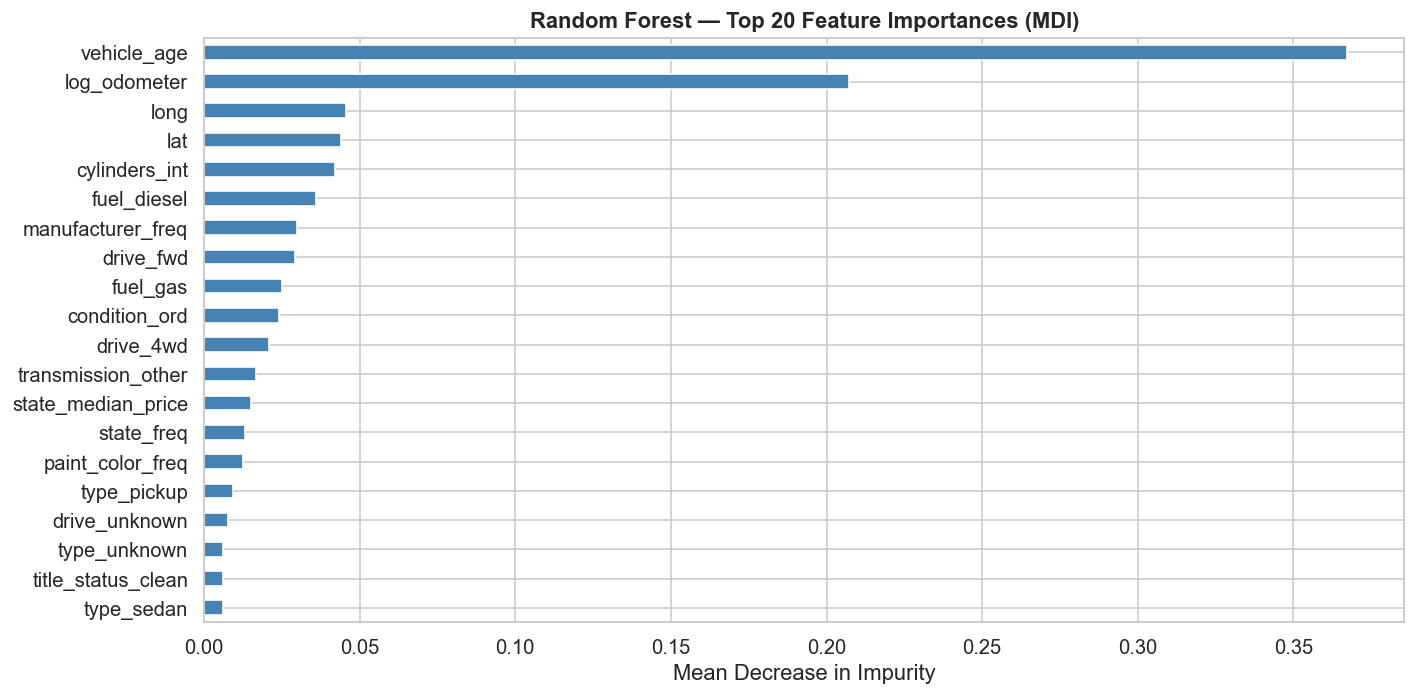

In [7]:
# Top-20 built-in feature importances
fi_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fi_rf.head(20).sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('../reports/figures/03_02_rf_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 4. XGBoost <a id='4-xgb'></a>

XGBoost is a gradient-boosted tree model that typically achieves state-of-the-art performance on tabular data. We use early stopping on the validation set to avoid overfitting.

In [8]:
t0 = time.time()

xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=SEED,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'XGBoost trained in {time.time() - t0:.1f}s  |  best iteration: {xgb.best_iteration}')

res_xgb_train = evaluate(xgb, X_train, y_train, label='XGBoost')
res_xgb_val   = evaluate(xgb, X_val,   y_val,   label='XGBoost')

for label, res in [('Train', res_xgb_train), ('Validation', res_xgb_val)]:
    print(f'\n── {label} ──────────────────────────────')
    print(f"  RMSE (log) : {res['rmse_log']:.4f}")
    print(f"  MAE  (USD) : ${res['mae_usd']:,.0f}")
    print(f"  R²         : {res['r2']:.4f}")
    print(f"  MAPE       : {res['mape']:.1f}%")

XGBoost trained in 56.9s  |  best iteration: 1499

── Train ──────────────────────────────
  RMSE (log) : 0.3144
  MAE  (USD) : $3,088
  R²         : 0.8789
  MAPE       : 24.1%

── Validation ──────────────────────────────
  RMSE (log) : 0.3521
  MAE  (USD) : $3,283
  R²         : 0.8482
  MAPE       : 28.2%


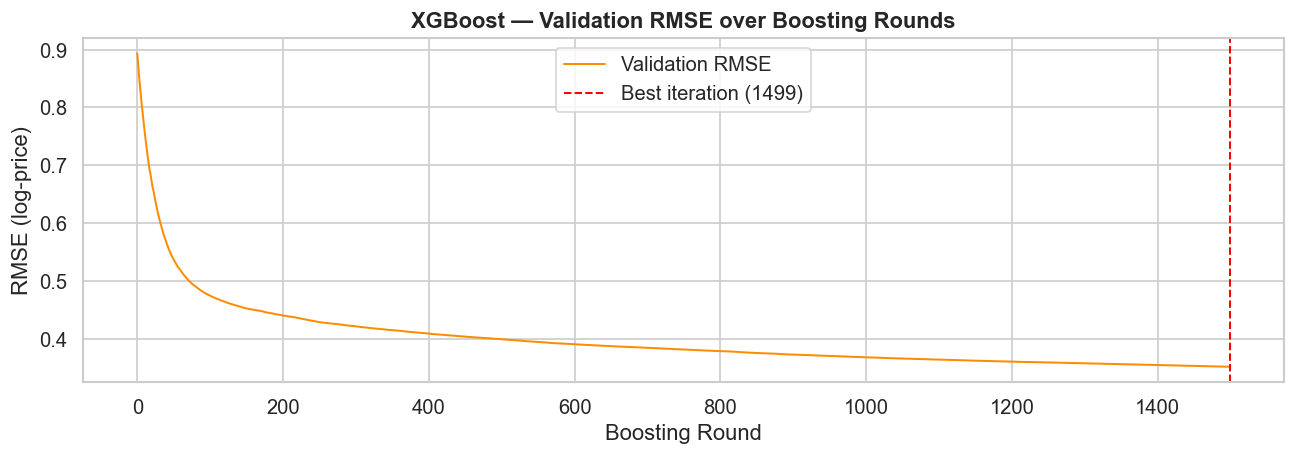

In [9]:
# XGBoost learning curve (train vs val RMSE over boosting rounds)
results = xgb.evals_result()
val_rmse = results['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(val_rmse, color='darkorange', linewidth=1.2, label='Validation RMSE')
ax.axvline(xgb.best_iteration, color='red', linestyle='--', linewidth=1.2,
           label=f'Best iteration ({xgb.best_iteration})')
ax.set_title('XGBoost — Validation RMSE over Boosting Rounds', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (log-price)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_03_xgb_learning_curve.png', bbox_inches='tight')
plt.show()

---
## 5. LightGBM <a id='5-lgbm'></a>

LightGBM is a faster alternative to XGBoost that uses leaf-wise tree growth. It often matches or beats XGBoost on large tabular datasets while training significantly faster.

In [10]:
t0 = time.time()

lgbm = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        __import__('lightgbm').early_stopping(stopping_rounds=50, verbose=False),
        __import__('lightgbm').log_evaluation(period=-1)
    ]
)

print(f'LightGBM trained in {time.time() - t0:.1f}s  |  best iteration: {lgbm.best_iteration_}')

res_lgbm_train = evaluate(lgbm, X_train, y_train, label='LightGBM')
res_lgbm_val   = evaluate(lgbm, X_val,   y_val,   label='LightGBM')

for label, res in [('Train', res_lgbm_train), ('Validation', res_lgbm_val)]:
    print(f'\n── {label} ──────────────────────────────')
    print(f"  RMSE (log) : {res['rmse_log']:.4f}")
    print(f"  MAE  (USD) : ${res['mae_usd']:,.0f}")
    print(f"  R²         : {res['r2']:.4f}")
    print(f"  MAPE       : {res['mape']:.1f}%")

LightGBM trained in 32.5s  |  best iteration: 1500

── Train ──────────────────────────────
  RMSE (log) : 0.2794
  MAE  (USD) : $2,768
  R²         : 0.9044
  MAPE       : 20.5%

── Validation ──────────────────────────────
  RMSE (log) : 0.3315
  MAE  (USD) : $3,056
  R²         : 0.8654
  MAPE       : 25.5%


---
## 6. Model Comparison <a id='6-compare'></a>

In [11]:
all_val_results = [
    res_ridge_val,
    res_rf_val,
    res_xgb_val,
    res_lgbm_val,
]

print('=== Validation Set Results (sorted by RMSE log-price) ===')
compare_models(all_val_results)

=== Validation Set Results (sorted by RMSE log-price) ===


,rmse_log,mae_usd,r2,mape
label,,,,
LightGBM,0.3315,"$3,056",0.8654,25.5%
XGBoost,0.3521,"$3,283",0.8482,28.2%
Random Forest,0.3695,"$2,991",0.8328,30.0%
Ridge,0.6093,"$6,167",0.5453,71.2%


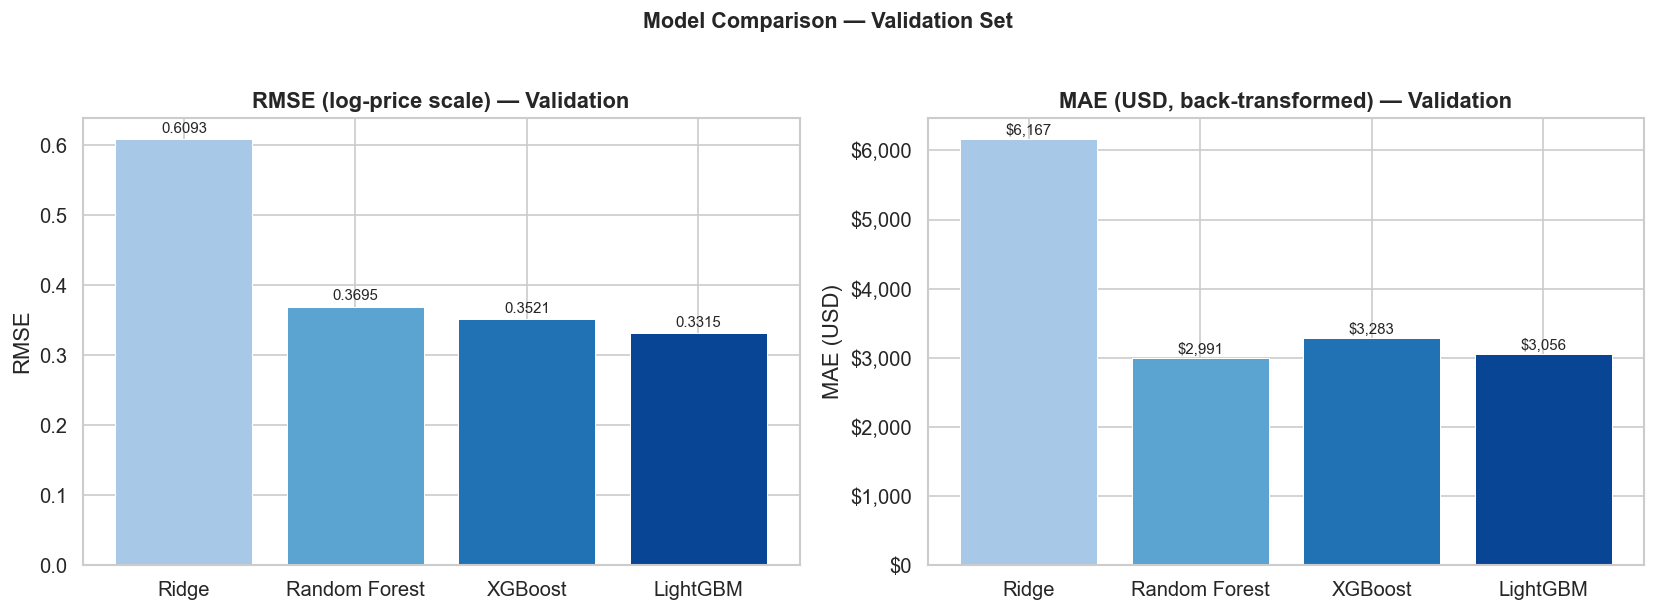

In [12]:
# Side-by-side bar chart comparison
models_names = ['Ridge', 'Random Forest', 'XGBoost', 'LightGBM']
rmse_vals = [res_ridge_val['rmse_log'], res_rf_val['rmse_log'],
             res_xgb_val['rmse_log'],   res_lgbm_val['rmse_log']]
mae_vals  = [res_ridge_val['mae_usd'],  res_rf_val['mae_usd'],
             res_xgb_val['mae_usd'],    res_lgbm_val['mae_usd']]

colors = ['#a8c8e8', '#5ba3d0', '#2171b5', '#084594']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(models_names, rmse_vals, color=colors, edgecolor='white', linewidth=0.6)
axes[0].set_title('RMSE (log-price scale) — Validation', fontweight='bold')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

bars = axes[1].bar(models_names, mae_vals, color=colors, edgecolor='white', linewidth=0.6)
axes[1].set_title('MAE (USD, back-transformed) — Validation', fontweight='bold')
axes[1].set_ylabel('MAE (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_04_model_comparison.png', bbox_inches='tight')
plt.show()

**LightGBM wins** on RMSE (0.3315 vs 0.3521 for XGBoost) and R² (0.8654 vs 0.8482), while training ~1.5x faster (32.5s vs 56.9s). Interestingly, Random Forest achieves the lowest raw MAE ($2,991) but at a much worse RMSE and MAPE, suggesting it handles mid-range prices well but struggles at the extremes. LightGBM will be used as the **best model** for the final test-set evaluation and as the target for XAI analysis in Notebook 04.

---
## 7. Best Model — Validation Deep-Dive <a id='7-deepdive'></a>

We now evaluate LightGBM more thoroughly: predicted vs actual, residual distribution, error by price segment, and permutation feature importance.

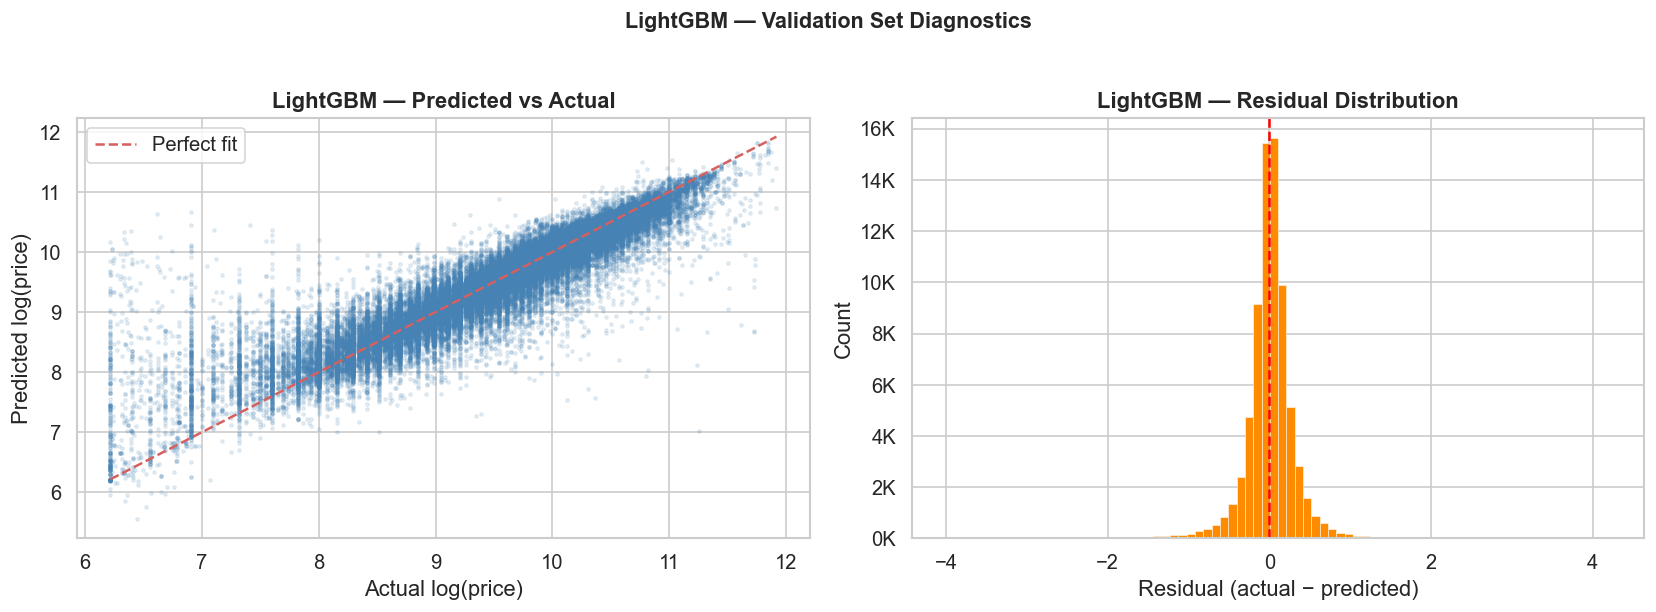

In [15]:
y_pred_lgbm = lgbm.predict(X_val)
residuals   = y_val - y_pred_lgbm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_val, y_pred_lgbm, alpha=0.12, s=4, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('LightGBM — Predicted vs Actual', fontweight='bold')
axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('LightGBM — Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('LightGBM — Validation Set Diagnostics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_05_lgbm_diagnostics.png', bbox_inches='tight')
plt.show()

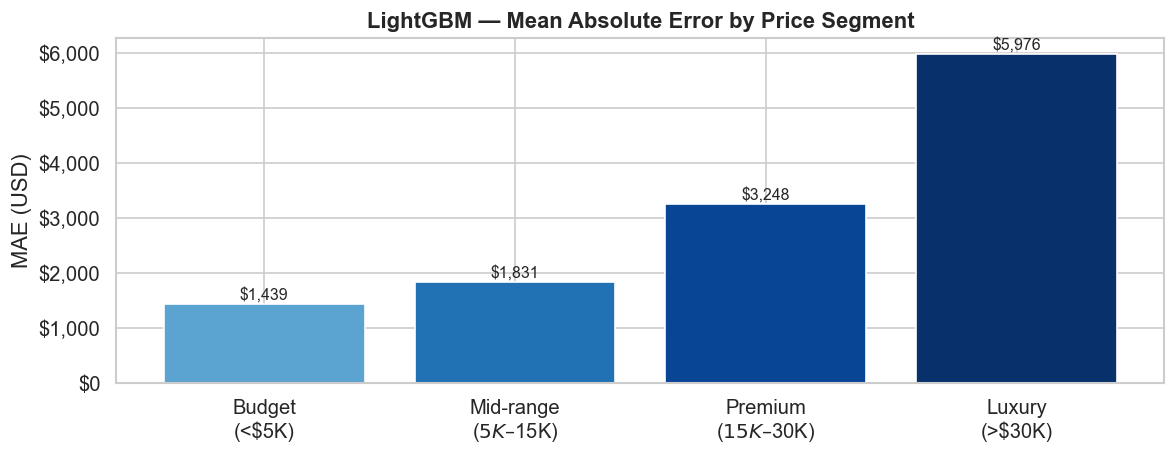

In [18]:
# MAE by price segment (cheap / mid / premium)
y_true_usd = np.expm1(y_val)
y_pred_usd = np.expm1(y_pred_lgbm)
abs_err    = np.abs(y_true_usd - y_pred_usd)

segment = pd.cut(
    y_true_usd,
    bins=[0, 5_000, 15_000, 30_000, 150_000],
    labels=['Budget\n(<$5K)', 'Mid-range\n($5K–$15K)',
            'Premium\n($15K–$30K)', 'Luxury\n(>$30K)']
)
mae_by_seg = pd.Series(abs_err).groupby(segment).mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(mae_by_seg.index, mae_by_seg.values,
              color=['#5ba3d0', '#2171b5', '#084594', '#08306b'], edgecolor='white')
ax.set_title('LightGBM — Mean Absolute Error by Price Segment', fontweight='bold')
ax.set_ylabel('MAE (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, mae_by_seg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9.5)
plt.tight_layout()
plt.savefig('../reports/figures/03_06_lgbm_mae_by_segment.png', bbox_inches='tight')
plt.show()

Computing permutation importance on 5,000-row sample (n_repeats=5) ...
Done in 166.1s


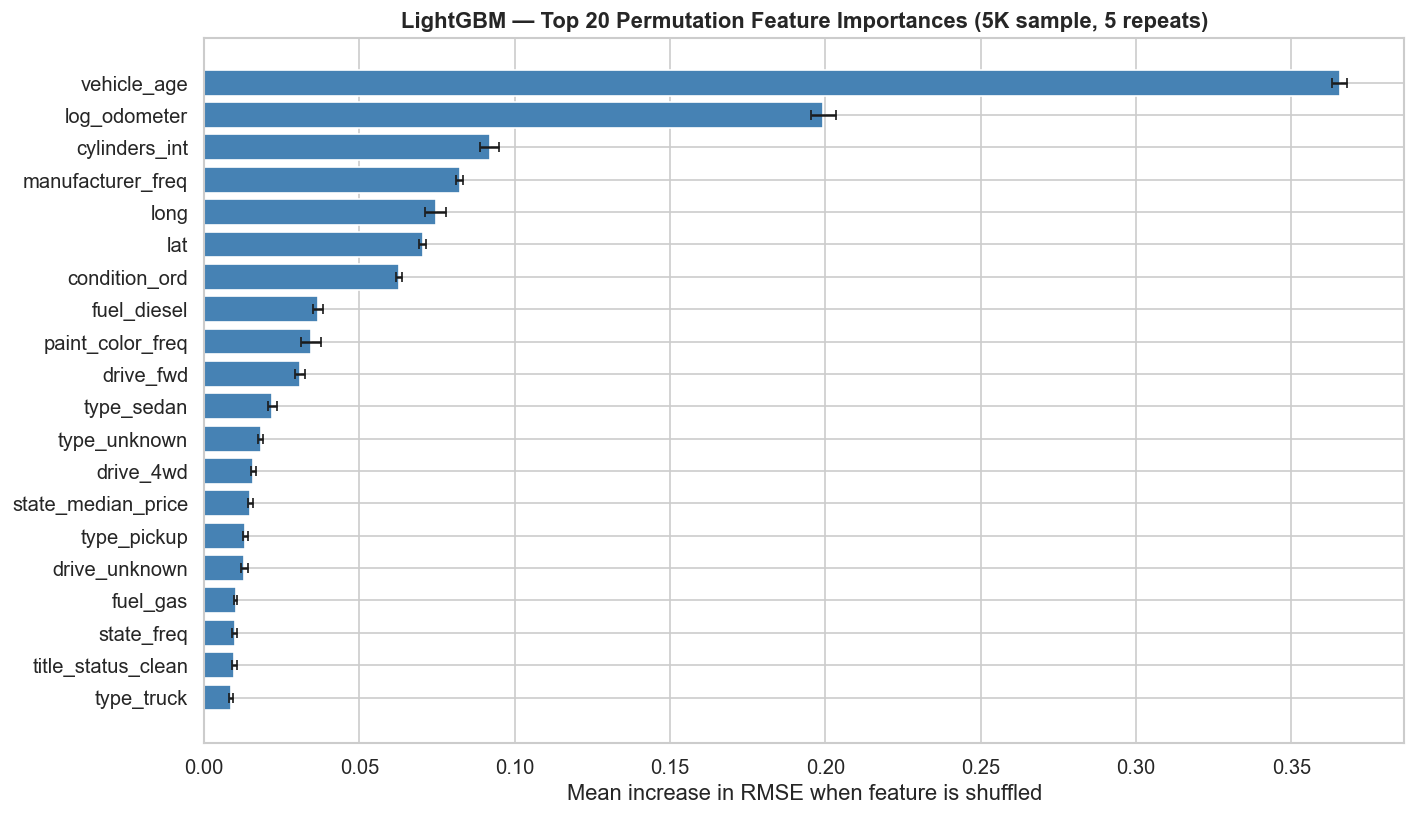

In [20]:
# Permutation Feature Importance — using a small sample to keep it fast
print('Computing permutation importance on 5,000-row sample (n_repeats=5) ...')
t0 = time.time()

# Sample down — permutation importance doesn't need the full validation set
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_val), size=5_000, replace=False)
X_val_sample = X_val[sample_idx]
y_val_sample  = y_val[sample_idx]

perm = permutation_importance(
    lgbm, X_val_sample, y_val_sample,
    n_repeats=5,               # reduced from 10
    random_state=SEED,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
print(f'Done in {time.time() - t0:.1f}s')

perm_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color='steelblue',
        edgecolor='white', capsize=3)
ax.set_title('LightGBM — Top 20 Permutation Feature Importances (5K sample, 5 repeats)',
             fontweight='bold')
ax.set_xlabel('Mean increase in RMSE when feature is shuffled')
plt.tight_layout()
plt.savefig('../reports/figures/03_07_lgbm_permutation_importance.png', bbox_inches='tight')
plt.show()

---
## 8. Save Best Model <a id='8-save'></a>

We evaluate the final model on the **held-out test set** (used only once) and save everything needed for the XAI notebook.

In [21]:
res_lgbm_test = evaluate(lgbm, X_test, y_test, label='LightGBM')

print('=== FINAL TEST SET RESULTS — LightGBM ===')
print(f"\n  RMSE (log) : {res_lgbm_test['rmse_log']:.4f}")
print(f"  MAE  (USD) : ${res_lgbm_test['mae_usd']:,.0f}")
print(f"  R²         : {res_lgbm_test['r2']:.4f}")
print(f"  MAPE       : {res_lgbm_test['mape']:.1f}%")
print(f"\nTest vs Validation gap:")
print(f"  ΔRMSE (log) : {res_lgbm_test['rmse_log'] - res_lgbm_val['rmse_log']:+.4f}  (expected — no leakage)")

=== FINAL TEST SET RESULTS — LightGBM ===

  RMSE (log) : 0.3328
  MAE  (USD) : $3,079
  R²         : 0.8637
  MAPE       : 25.6%

Test vs Validation gap:
  ΔRMSE (log) : +0.0012  (expected — no leakage)


In [22]:
import os
os.makedirs('../models', exist_ok=True)

print('Saving artifacts ...')

# Best model
joblib.dump(lgbm, '../models/lgbm_best.joblib')
print('  ../models/lgbm_best.joblib         ✓')

# Validation sample for XAI (LIME / SHAP local explanations)
xai_val_sample = df_val_m[FEATURE_COLS].sample(n=5_000, random_state=SEED)
xai_val_sample.to_parquet('../models/X_val_sample.parquet', index=False)
print('  ../models/X_val_sample.parquet     ✓  (5,000 rows for XAI)')

# Train sample as SHAP background dataset
xai_train_sample = df_train_m[FEATURE_COLS].sample(n=10_000, random_state=SEED)
xai_train_sample.to_parquet('../models/X_train_sample.parquet', index=False)
print('  ../models/X_train_sample.parquet   ✓  (10,000 rows for SHAP background)')

print('Done.')

Saving artifacts ...
  ../models/lgbm_best.joblib         ✓
  ../models/X_val_sample.parquet     ✓  (5,000 rows for XAI)
  ../models/X_train_sample.parquet   ✓  (10,000 rows for SHAP background)
Done.


In [23]:
# Pass forward to 04_XAI.ipynb
%store lgbm
%store FEATURE_COLS
%store X_train
%store X_val
%store y_val

print('Stored for 04_XAI.ipynb: lgbm, FEATURE_COLS, X_train, X_val, y_val')

Stored 'lgbm' (LGBMRegressor)
Stored 'FEATURE_COLS' (list)
Stored 'X_train' (ndarray)
Stored 'X_val' (ndarray)
Stored 'y_val' (ndarray)
Stored for 04_XAI.ipynb: lgbm, FEATURE_COLS, X_train, X_val, y_val


---
### Summary

| Model | Val RMSE (log) | Val MAE (USD) | Val R² | Val MAPE |
|---|---|---|---|---|
| Ridge | 0.6093 | $6,167 | 0.5453 | 71.2% |
| Random Forest | 0.3695 | $2,991 | 0.8328 | 30.0% |
| XGBoost | 0.3521 | $3,283 | 0.8482 | 28.2% |
| **LightGBM** | **0.3315** | **$3,056** | **0.8654** | **25.5%** |

**LightGBM** is selected as the best model. On the held-out test set it achieves **RMSE = 0.3328**, **MAE = $3,079**, **R² = 0.8637**, **MAPE = 25.6%** — gap of only +0.0012 RMSE vs validation, confirming no overfitting.

*Proceed to `04_XAI.ipynb` for SHAP, LIME, PDP, and ICE analysis.*